In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [64]:
df=pd.read_csv('/Users/priyanshugupta/Desktop/scikit learn/creditcard.csv')
df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


In [65]:
df['Class'].value_counts() ## Imbalanced dataset

Class
0    284315
1       492
Name: count, dtype: int64

<Axes: xlabel='Class'>

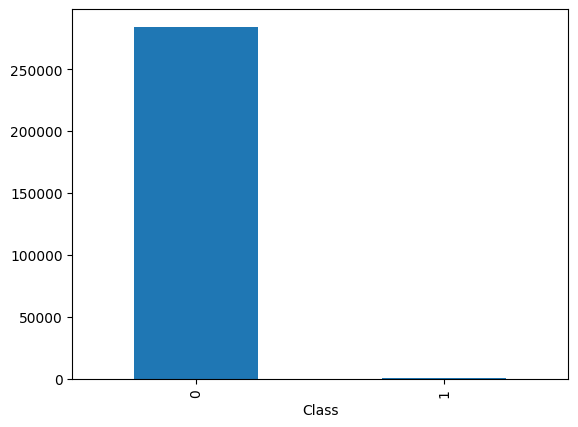

In [66]:
df['Class'].value_counts().plot(kind='bar')

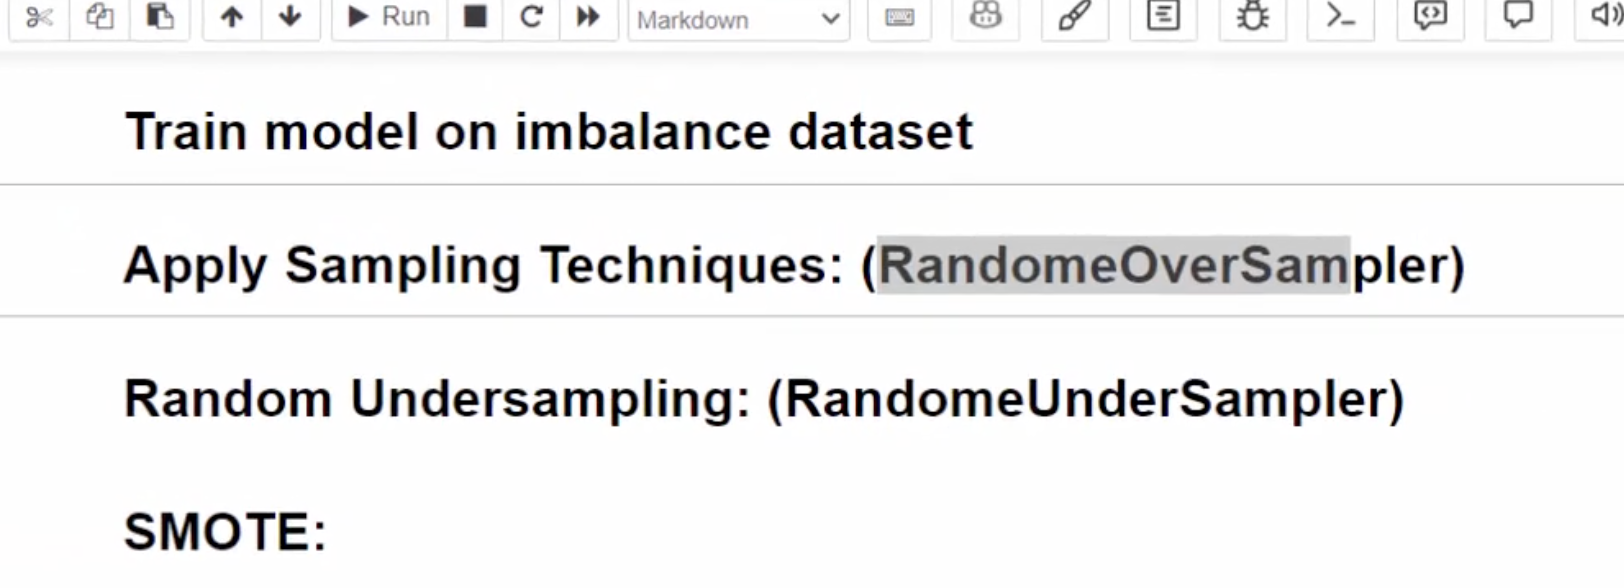

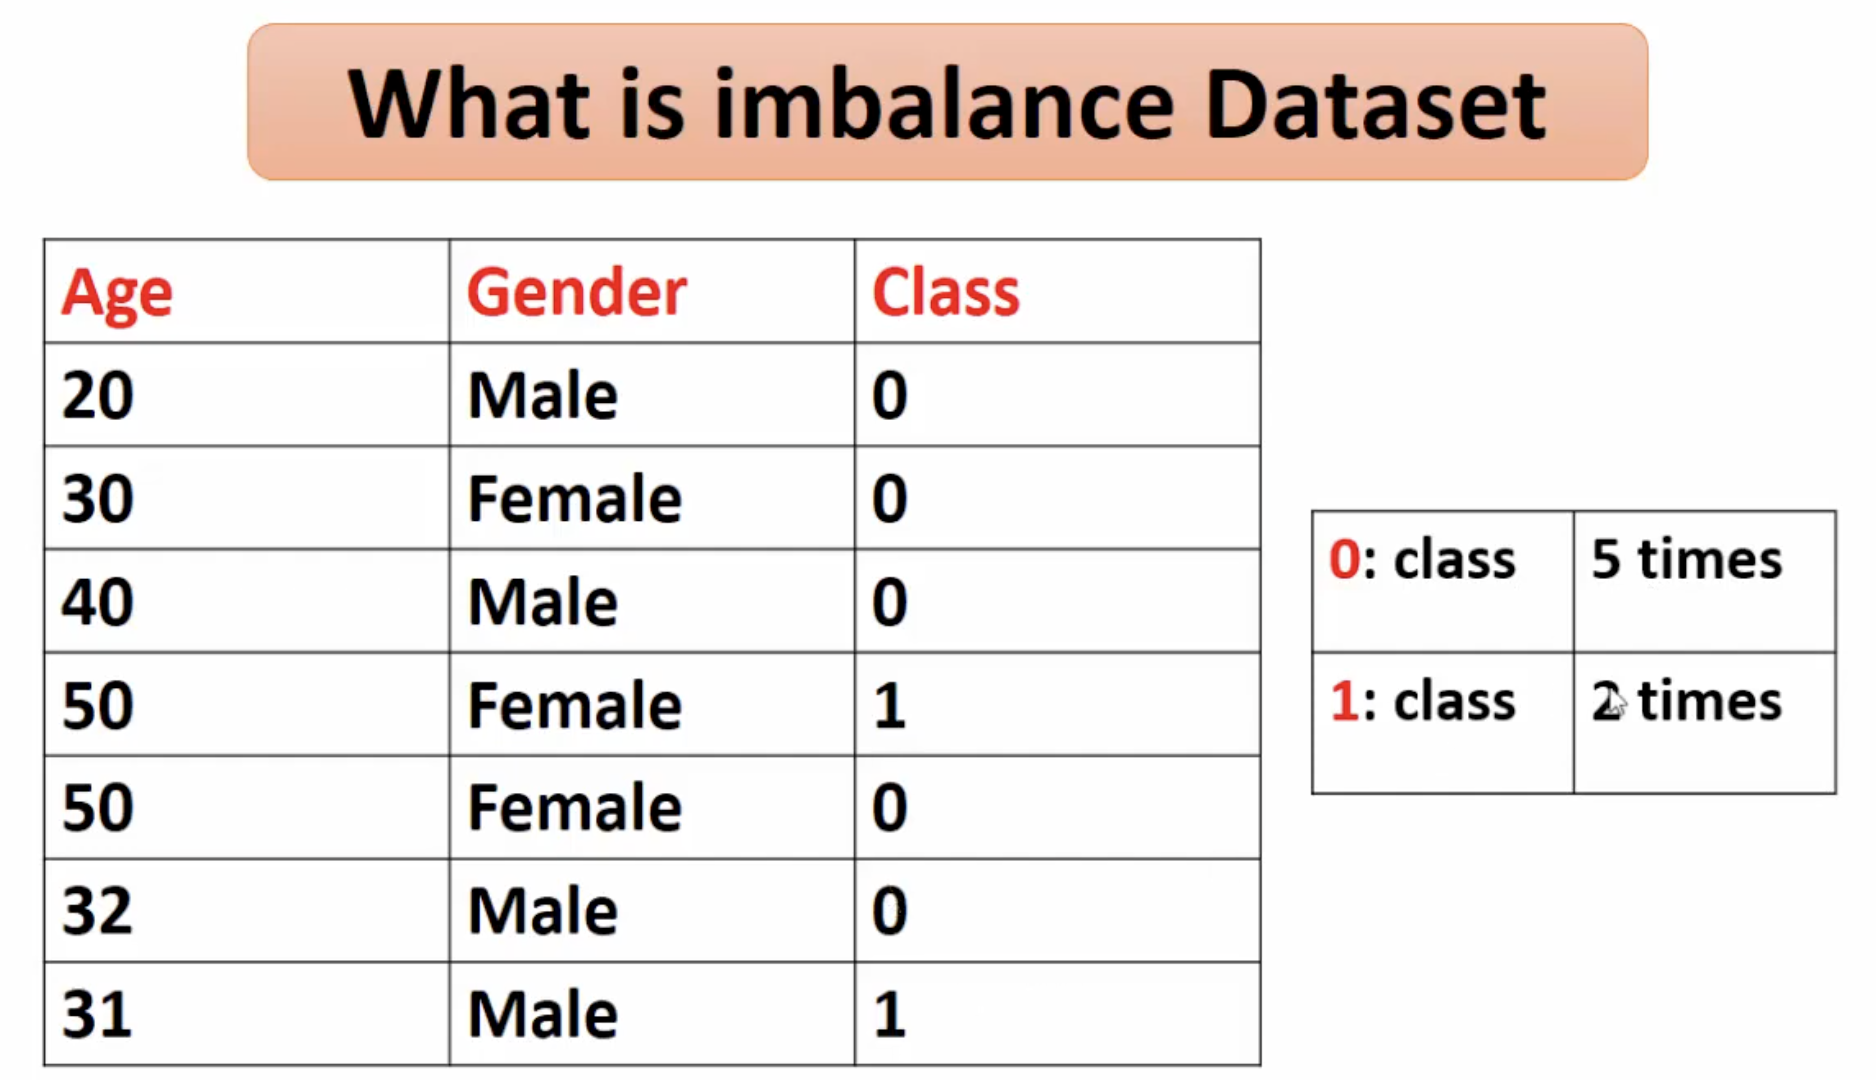

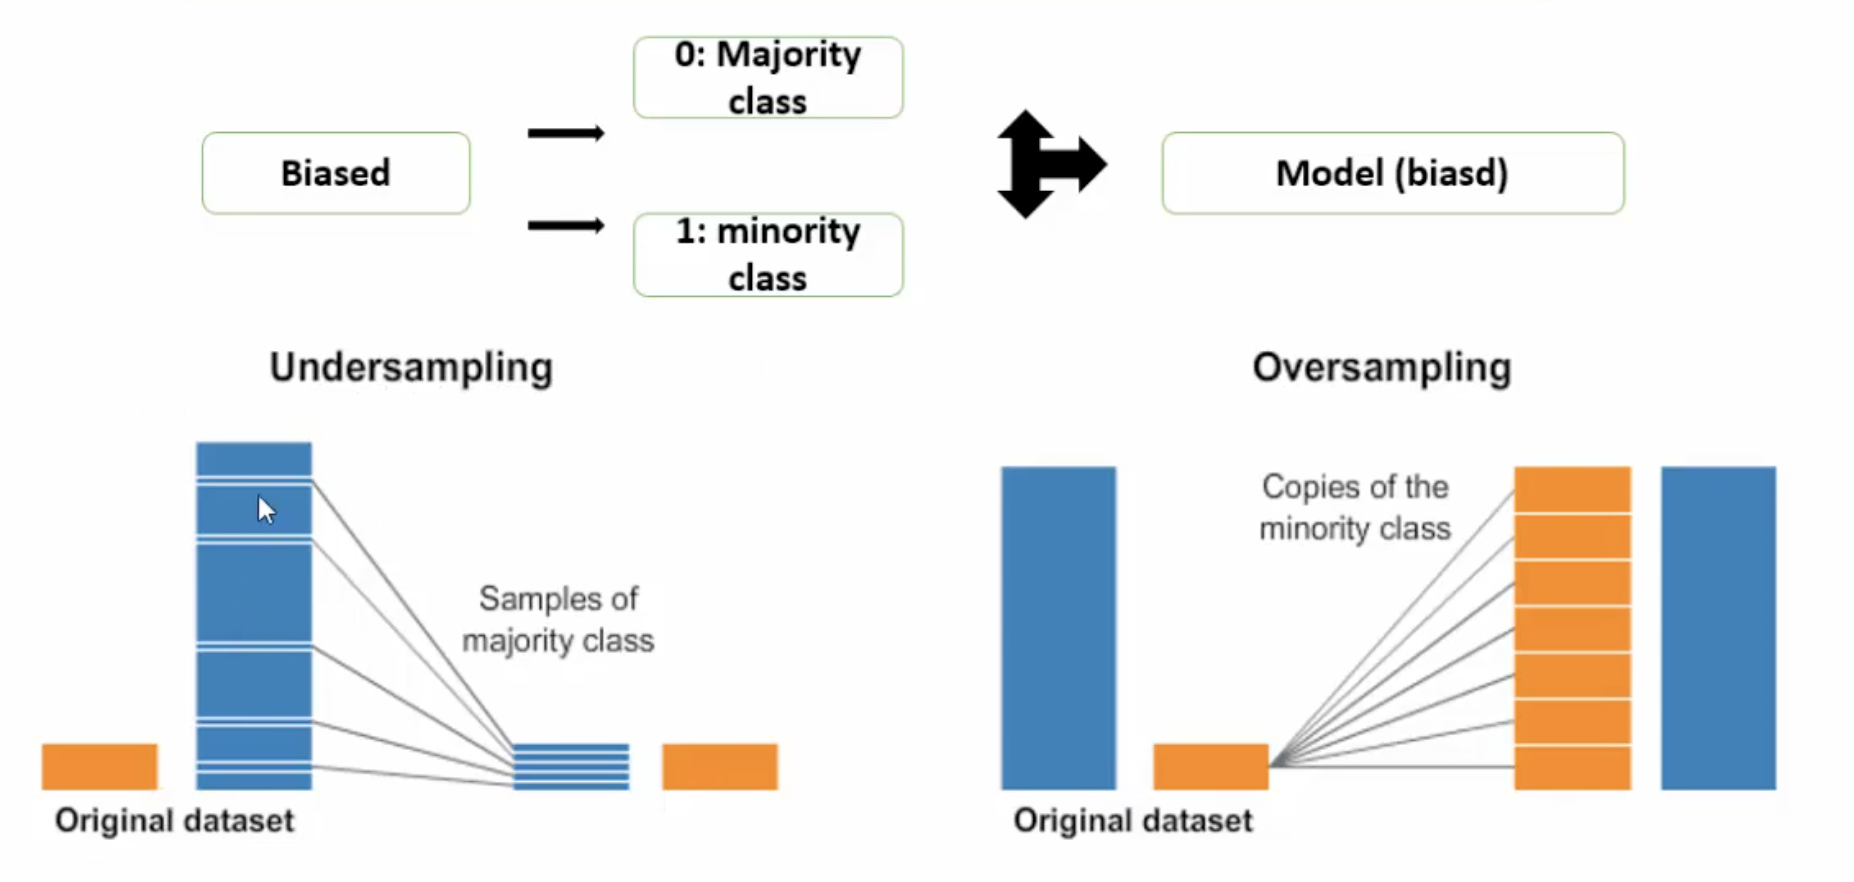

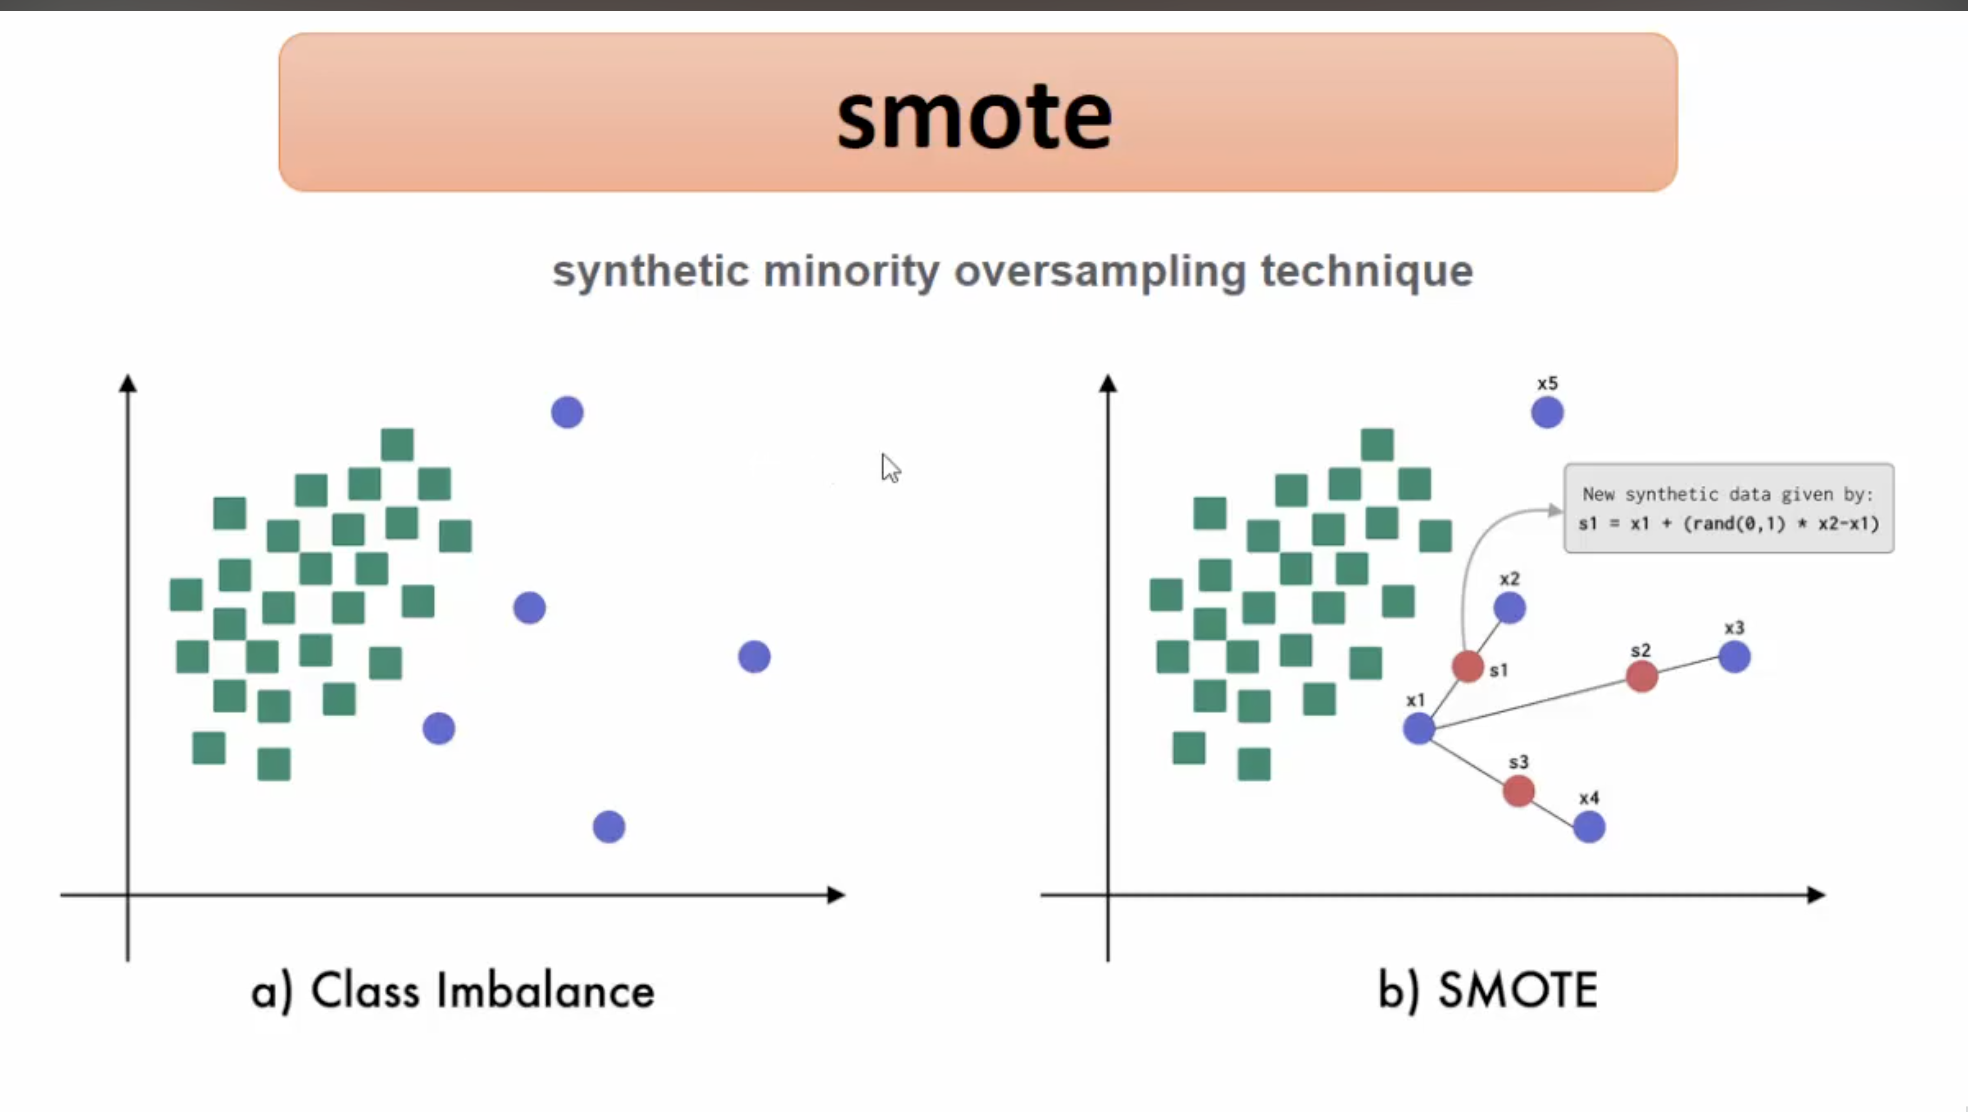

In [67]:
df.shape

(284807, 31)

In [68]:
df=df.sample(20000)
df['Class'].value_counts()

Class
0    19970
1       30
Name: count, dtype: int64

## Training model on imbalanced dataset

In [69]:
from sklearn.model_selection import train_test_split
X=df.drop('Class',axis=1)
y=df['Class']

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=20)


In [70]:
from sklearn.ensemble import RandomForestClassifier
rf_model=RandomForestClassifier()
rf_model.fit(X_train,y_train)

## prediction
y_pred=rf_model.predict(X_test)

## cal confusion matrix

from sklearn.metrics import confusion_matrix,classification_report

conf_matrix=confusion_matrix(y_test,y_pred)
print('confusion matrix:')
print(conf_matrix)

print('classification_report')
class_report=classification_report(y_test,y_pred)
print(class_report)


## calculate accuracy 
accuracy=rf_model.score(X_test,y_test)
print('accuracy:',accuracy)

confusion matrix:
[[3993    2]
 [   4    1]]
classification_report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3995
           1       0.33      0.20      0.25         5

    accuracy                           1.00      4000
   macro avg       0.67      0.60      0.62      4000
weighted avg       1.00      1.00      1.00      4000

accuracy: 0.9985


## Applying sampling technique 

## RandomOverSampler

In [71]:
from imblearn.over_sampling import RandomOverSampler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report,confusion_matrix

## initalize RandomOverSampler
ros=RandomOverSampler()

## perform Random_oversampling
X_ros,y_ros=ros.fit_resample(X_train,y_train)

In [72]:
y_ros.value_counts()

Class
0    15975
1    15975
Name: count, dtype: int64

In [73]:
## Initalize the model
rf_model_ros=RandomForestClassifier()

## train the model on Random_oversampled_data
rf_model_ros.fit(X_ros,y_ros)

## predict on test set 

y_pred_ros=rf_model.predict(X_test)

## confusion matrix

conf_matrix_ros=confusion_matrix(y_test,y_pred_ros)
print('confusion matrix(Random Oversampling):')
print(conf_matrix_ros)

## classification report

class_report_ros=classification_report(y_test,y_pred_ros)
print('classification report (Random Oversampling):')
print(class_report_ros)

## cal accuracy

accuracy_ros=rf_model_ros.score(X_test,y_pred_ros)
print('Accuracy (Random Oversampling):',accuracy_ros)

confusion matrix(Random Oversampling):
[[3993    2]
 [   4    1]]
classification report (Random Oversampling):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3995
           1       0.33      0.20      0.25         5

    accuracy                           1.00      4000
   macro avg       0.67      0.60      0.62      4000
weighted avg       1.00      1.00      1.00      4000

Accuracy (Random Oversampling): 0.9995


## Random Undersampling(RandomUnderSampler)

In [74]:
from imblearn.under_sampling import RandomUnderSampler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report,confusion_matrix

## initalize RandomUnderSampler
rus=RandomUnderSampler()

## perform Random Undersampling
X_rus,y_rus=rus.fit_resample(X_train,y_train)

y_rus.value_counts()

Class
0    25
1    25
Name: count, dtype: int64

In [75]:
## Initalize the model
rf_model_rus=RandomForestClassifier()

## train the model on Random_oversampled_data
rf_model_rus.fit(X_rus,y_rus)

## predict on test set 

y_pred_rus=rf_model.predict(X_test)

## confusion matrix

conf_matrix_rus=confusion_matrix(y_test,y_pred_rus)
print('confusion matrix(Random Undersampling):')
print(conf_matrix_rus)

## classification report

class_report_rus=classification_report(y_test,y_pred_rus)
print('classification report (Random Undersampling):')
print(class_report_rus)

## cal accuracy

accuracy_rus=rf_model_rus.score(X_test,y_pred_rus)
print('Accuracy (Random Oversampling):',accuracy_rus)

confusion matrix(Random Undersampling):
[[3993    2]
 [   4    1]]
classification report (Random Undersampling):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3995
           1       0.33      0.20      0.25         5

    accuracy                           1.00      4000
   macro avg       0.67      0.60      0.62      4000
weighted avg       1.00      1.00      1.00      4000

Accuracy (Random Oversampling): 0.99175


## Smote is similar to RandomOversampler 

Difference is it doesn't just produce exact duplicate data like randomoversampler it creates augmented data instad(synthetic data)

In [76]:
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report,confusion_matrix
from sklearn.ensemble import RandomForestClassifier


## Initalize SMOTE
smote=SMOTE()

## PERFORM SMOTE

X_smote,y_smote=smote.fit_resample(X_train,y_train)

y_smote.value_counts()

Class
0    15975
1    15975
Name: count, dtype: int64

In [77]:
## Initalize the model
rf_model_smote=RandomForestClassifier()

## train the model on Random_oversampled_data
rf_model_smote.fit(X_smote,y_smote)

## predict on test set 

y_pred_smote=rf_model.predict(X_test)

## confusion matrix

conf_matrix_smote=confusion_matrix(y_test,y_pred_smote)
print('confusion matrix(SMOTE):')
print(conf_matrix_smote)

## classification report

class_report_smote=classification_report(y_test,y_pred_smote)
print('classification report (SMOTE):')
print(class_report_smote)

## cal accuracy

accuracy_smote=rf_model_rus.score(X_test,y_pred_smote)
print('Accuracy (SMOTE):',accuracy_smote)

confusion matrix(SMOTE):
[[3993    2]
 [   4    1]]
classification report (SMOTE):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3995
           1       0.33      0.20      0.25         5

    accuracy                           1.00      4000
   macro avg       0.67      0.60      0.62      4000
weighted avg       1.00      1.00      1.00      4000

Accuracy (SMOTE): 0.99175
